## Understanding the Sigmoid Function

- The **[Sigmoid function](ca://s?q=Explain_sigmoid_function_in_ML)** is central to logistic regression and neural networks.  
- It transforms any real number into a value between **0 and 1**, making it perfect for representing probabilities.  
- Key characteristics:  
  - Smooth and differentiable curve.  
  - Symmetric around 0.  
  - Output always bounded between 0 and 1.  
- In **[Logistic Regression](ca://s?q=Logistic_Regression_in_machine_learning)**, the sigmoid takes the linear combination of inputs (\(w^T x + b\)) and converts it into a probability.  
- The **decision boundary** occurs at probability = 0.5, which corresponds to \(w^T x + b = 0\).  


In [1]:
from sklearn.datasets import make_classification
import numpy as np
X, y = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=10)

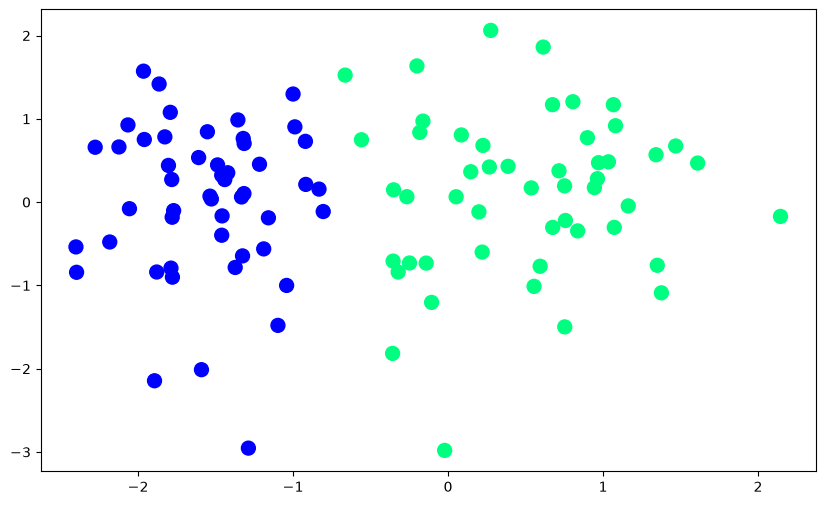

In [2]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.show()

In [3]:
def PerceptionSigmod(x,y,epoch,lr):
  x=np.insert(x,0,1,axis=1)
  coef=np.ones(x.shape[1])

  for i in range(epoch):
    j=np.random.randint(x.shape[0])
    yhat=sigma(np.dot(coef,x[j]))
    coef=coef+lr*(y[j]-yhat)*x[j]

  coef_=coef[1:]
  intercept_=coef[0]

  return (coef_,intercept_)

def sigma(val):
  return 1/(1+np.exp(-val))

In [4]:
coef_,intercept_=PerceptionSigmod(X,y,1500,0.2)

In [5]:
m=-(coef_[0]/coef_[1])
c=-(intercept_/coef_[1])

In [6]:
x_input=np.linspace(3,-3,X.shape[0])
y_input=m*x_input+c

In [7]:
from sklearn.linear_model import LogisticRegression
lr1=LogisticRegression()
lr1.fit(X,y)
coef_1,intercept_1=lr1.coef_,lr1.intercept_

In [8]:
m1 = -(coef_1[0][0]/coef_1[0][1])
b1 = -(intercept_1/coef_1[0][1])

In [9]:
x_input1 = np.linspace(-3,3,100)
y_input1 = m1*x_input1 + b1

(-3.0, 2.0)

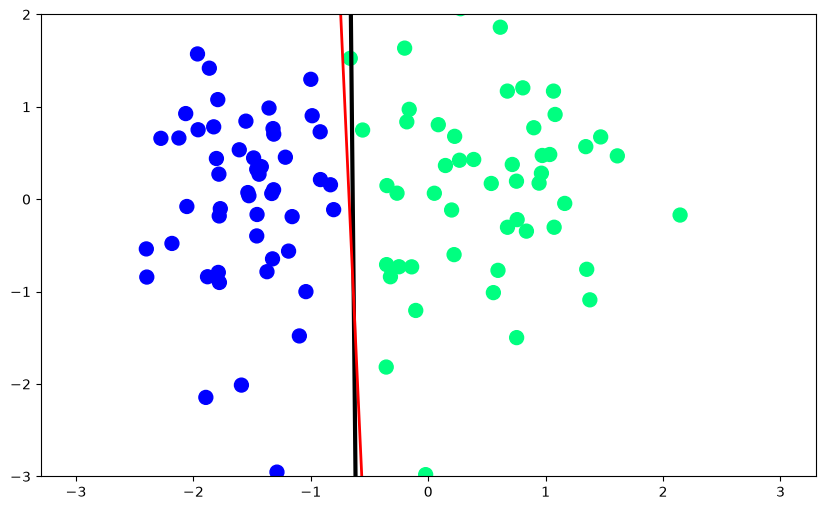

In [10]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.plot(x_input1,y_input1,color='black',linewidth=3)
plt.plot(x_input,y_input,color='red',linewidth=2)
plt.ylim(-3,2)